TASK 2: REGRESSION - LIFE EXPECTANCY PREDICTION

1. Basic Dataset Information:
Shape: (2938, 22)

Data Types:
Country                             object
Year                                 int64
Status                              object
Life expectancy                    float64
Adult Mortality                    float64
infant deaths                        int64
Alcohol                            float64
percentage expenditure             float64
Hepatitis B                        float64
Measles                              int64
 BMI                               float64
under-five deaths                    int64
Polio                              float64
Total expenditure                  float64
Diphtheria                         float64
 HIV/AIDS                          float64
GDP                                float64
Population                         float64
 thinness  1-19 years              float64
 thinness 5-9 years                float64
Income composition of resource

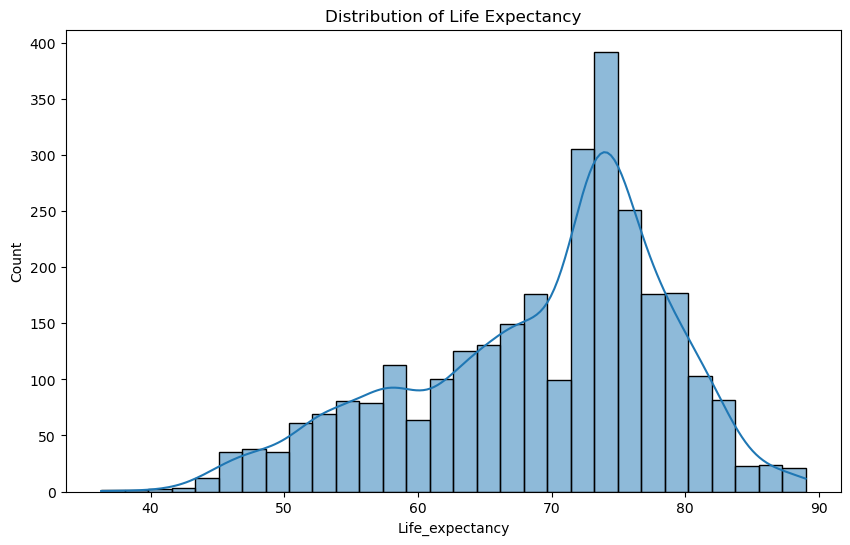

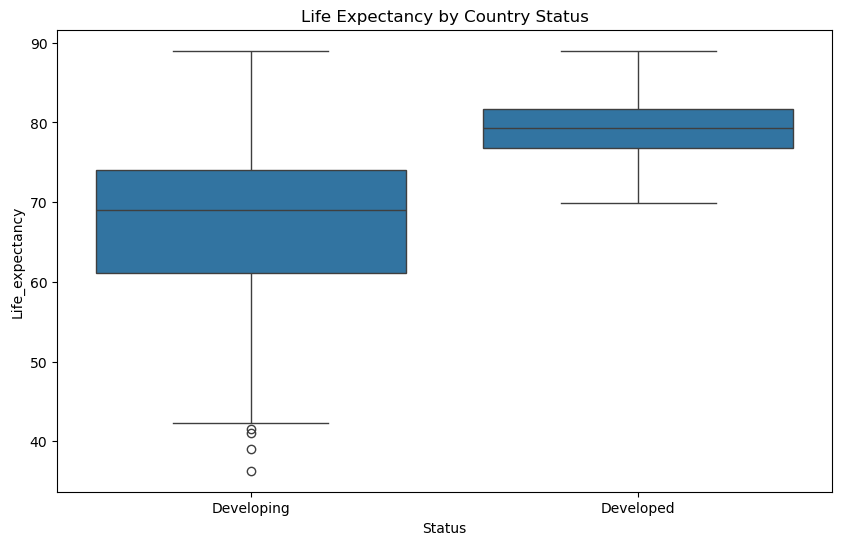

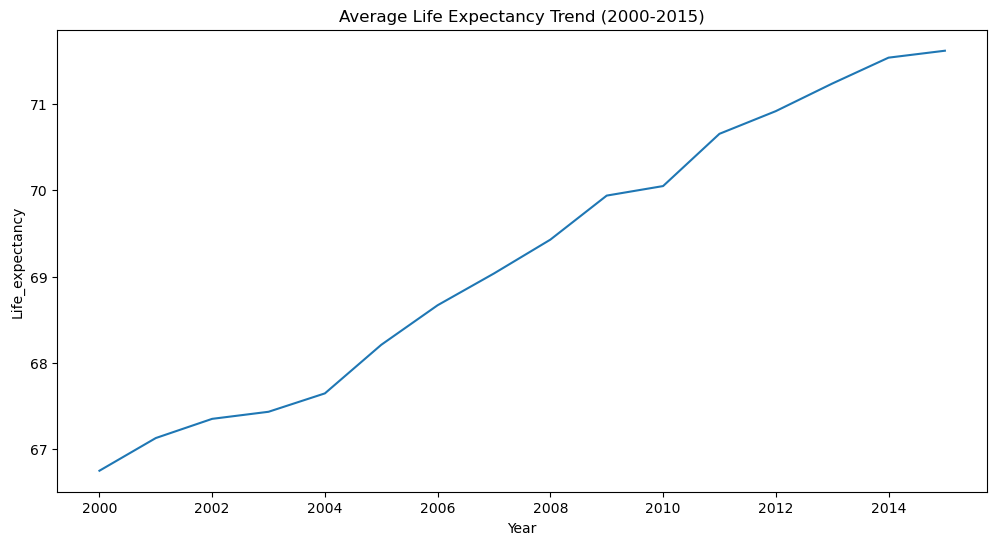

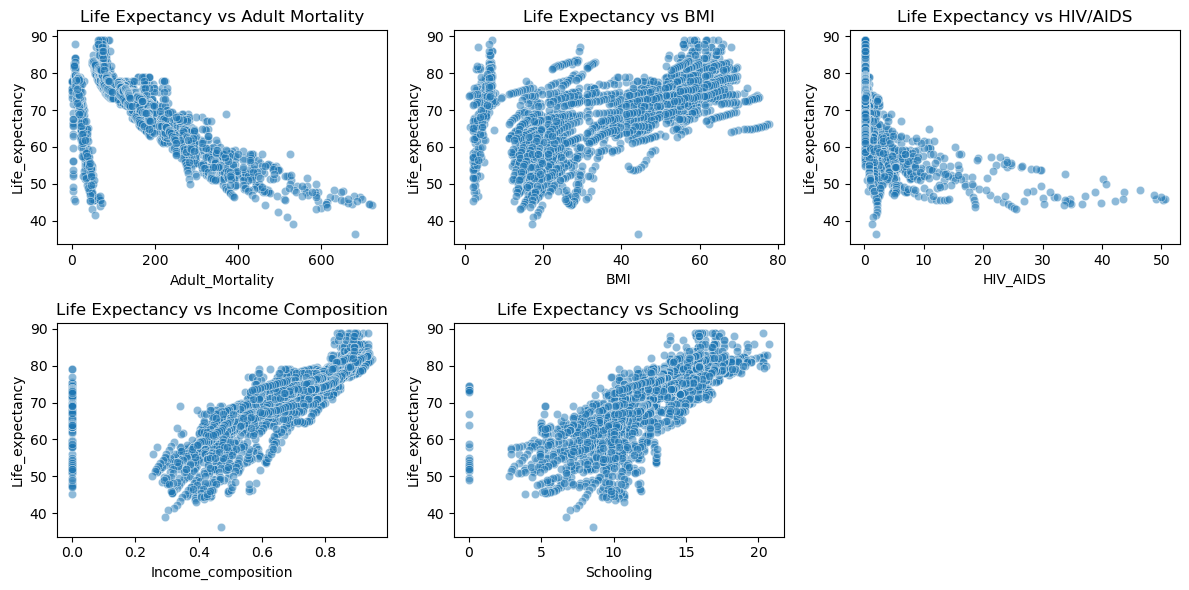

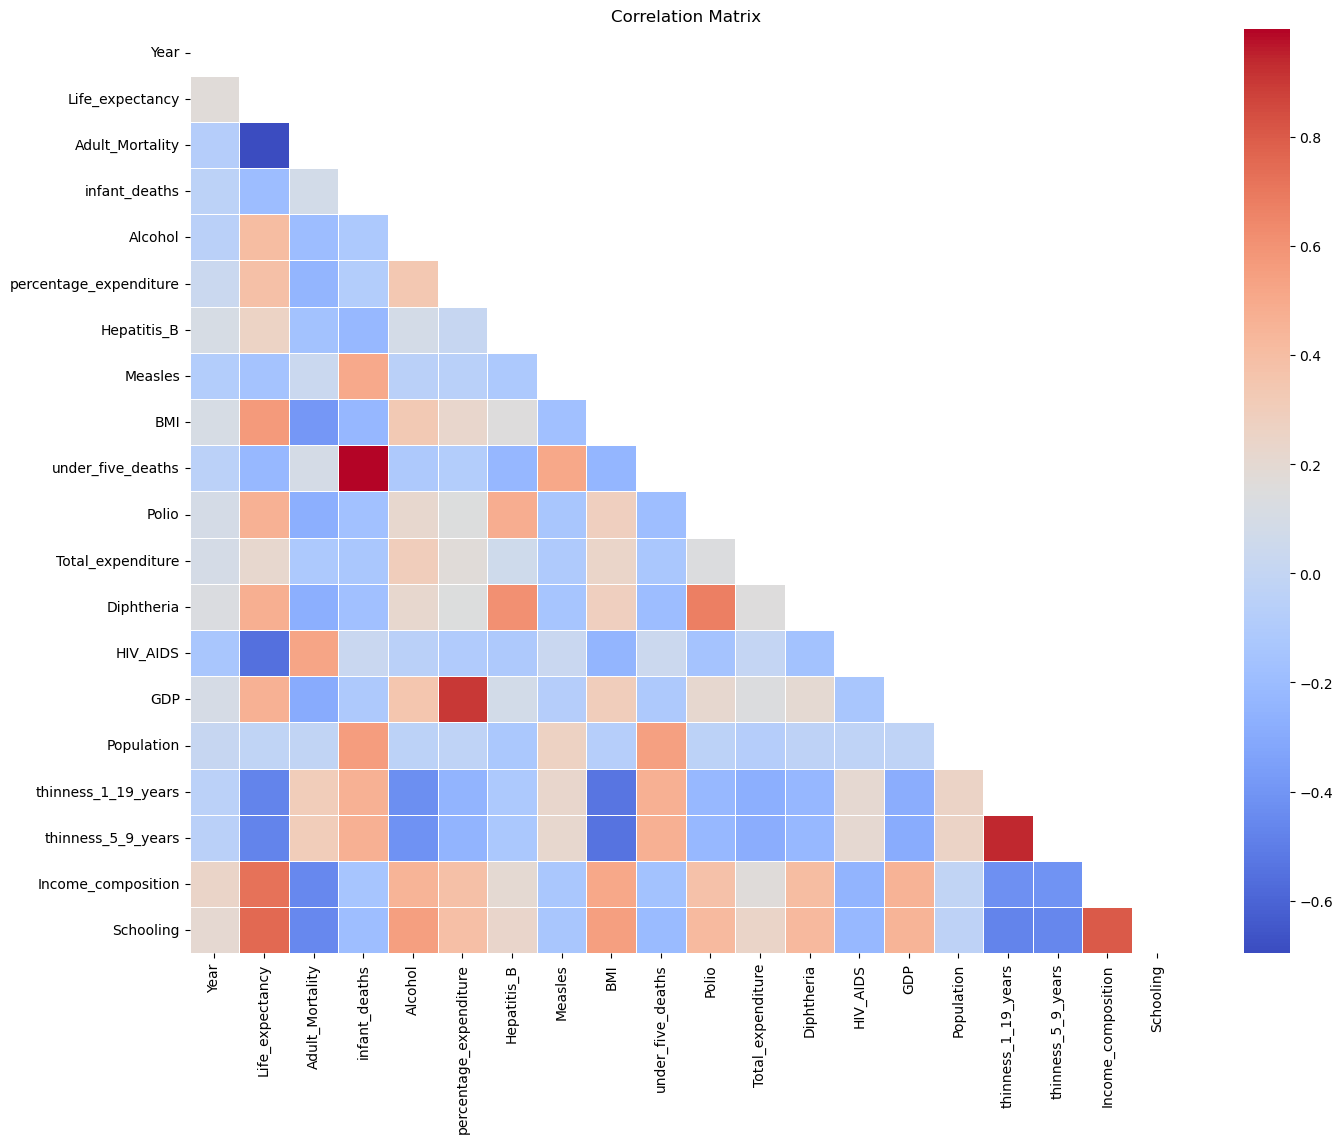

In [2]:
# Student: 371506 - Nina Nguyen
# Content: Task 2 Regression (Life Expectancy Prediction)
# Dataset: D4 - Life Expectancy Data.csv

# Step 1: Loading Data, Data Pre-processing, EDA
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import warnings
warnings.filterwarnings('ignore')

print("="*50)
print("TASK 2: REGRESSION - LIFE EXPECTANCY PREDICTION")
print("="*50)

# load the dataset
df = pd.read_csv('./Datasets/D4/Life Expectancy Data.csv')

# display basic information
print("\n1. Basic Dataset Information:")
print(f"Shape: {df.shape}")
print("\nData Types:")
print(df.dtypes)

# rename columns with spaces for easier handling (as this can cause issues)
print("\n2. Renaming columns to remove spaces and special characters")
df = df.rename(columns={'Life expectancy ': 'Life_expectancy',
                        'Adult Mortality': 'Adult_Mortality',
                        'infant deaths': 'infant_deaths',
                        'percentage expenditure': 'percentage_expenditure',
                        'Hepatitis B': 'Hepatitis_B',
                        'Measles ': 'Measles',
                        ' BMI ': 'BMI',
                        'under-five deaths ': 'under_five_deaths',
                        'Total expenditure': 'Total_expenditure',
                        'Diphtheria ': 'Diphtheria',
                        ' HIV/AIDS': 'HIV_AIDS',
                        ' thinness  1-19 years': 'thinness_1_19_years',
                        ' thinness 5-9 years': 'thinness_5_9_years',
                        'Income composition of resources': 'Income_composition'})

# check for missing values 
print("\n3. Checking for Missing Values:")
missing_values = df.isnull().sum()
print(missing_values)
print(f"Total missing values: {missing_values.sum()}")

# visualize the missing values
print("\nMissing values by column (True/False):")
print(df.isnull())

# check for duplicates 
print("\n4. Checking for Duplicates:")
duplicate_rows = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_rows}")

if duplicate_rows > 0:
    print("Removing duplicate rows...")
    df = df.drop_duplicates(inplace=True)

# sample data
print("\n5. Sample Data:")
print(df.head())

# statistical summary
print("\n6. Statistical Summary of Numerical Variables:")
print(df.describe())

# EDA
print("\n7. Performing EDA:")

# create a directory for EDA figures if it doesn't exist
import os
if not os.path.exists('eda_figures'):
    os.makedirs('eda_figures')

# Figure 1: Distribution of Life Expectancy
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='Life_expectancy', kde=True)
plt.title('Distribution of Life Expectancy')
plt.savefig('eda_figures/life_expectancy_distribution.png')

# Figure 2: Life Expectancy by Status (Developed vs Developing)
plt.figure(figsize=(10, 6))
sns.boxplot(x='Status', y='Life_expectancy', data=df)
plt.title('Life Expectancy by Country Status')
plt.savefig('eda_figures/life_expectancy_by_status.png')

# Figure 3: Life Expectancy by Year (trend over time)
plt.figure(figsize=(12, 6))
year_data = df.groupby('Year')['Life_expectancy'].mean().reset_index()
sns.lineplot(x='Year', y='Life_expectancy', data=year_data)
plt.title('Average Life Expectancy Trend (2000-2015)')
plt.savefig('eda_figures/life_expectancy_by_year.png')

# Figure 4: Correlation between key health factors and Life Expectancy
plt.figure(figsize=(12, 6))

# create subplots for key health factors
plt.subplot(2, 3, 1)
sns.scatterplot(x='Adult_Mortality', y='Life_expectancy', data=df, alpha=0.5)
plt.title('Life Expectancy vs Adult Mortality')

plt.subplot(2, 3, 2)
sns.scatterplot(x='BMI', y='Life_expectancy', data=df, alpha=0.5)
plt.title('Life Expectancy vs BMI')

plt.subplot(2, 3, 3)
sns.scatterplot(x='HIV_AIDS', y='Life_expectancy', data=df, alpha=0.5)
plt.title('Life Expectancy vs HIV/AIDS')

plt.subplot(2, 3, 4)
sns.scatterplot(x='Income_composition', y='Life_expectancy', data=df, alpha=0.5)
plt.title('Life Expectancy vs Income Composition')

plt.subplot(2, 3, 5)
sns.scatterplot(x='Schooling', y='Life_expectancy', data=df, alpha=0.5)
plt.title('Life Expectancy vs Schooling')

plt.tight_layout()
plt.savefig('eda_figures/life_expectancy_health_factors.png')

# Figure 5: Correlation matrix for numerical features
plt.figure(figsize=(16, 12))
# Calculate correlation 
numerical_df = df.select_dtypes(include=[np.number])
correlation = numerical_df.corr()

# create mask for upper triangle to avoid repetition
mask = np.triu(correlation)
sns.heatmap(correlation, annot=False, mask=mask, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Matrix')
plt.savefig('eda_figures/life_expectancy_correlation.png')

# top correlations with Life Expectancy
life_exp_corr = correlation['Life_expectancy'].sort_values(ascending=False)
print("\n8. Top Correlations with Life Expectancy:")
print(life_exp_corr.head(10))  # Top 10 positive correlations
print("\nBottom Correlations with Life Expectancy:")
print(life_exp_corr.tail(10))  # Top 10 negative correlations

In [3]:
# Step 2: Feature Engineering, Creating Train, and Test Datasets

# handle missing values using the techniques from the tutorial
# Strategy: Fill missing values with median for numerical columns
# using SimpleImputer
for column in df.columns:
    if df[column].dtype != 'object' and df[column].isnull().sum() > 0:
        print(f"Imputing missing values in column '{column}' using median strategy")
        imputer = SimpleImputer(strategy='median')
        df[[column]] = imputer.fit_transform(df[[column]])

# verify missing values are handled
print("Remaining missing values after imputation:")
print(df.isnull().sum().sum())

# one-hot encode categorical variables (Status)
# using get_dummies as shown in the tutorial
df_encoded = pd.get_dummies(df, columns=['Status'], drop_first=True)
print("Column 'Status' encoded as dummy variables")

# drop the Country column as it has too many categories for one-hot encoding
df_encoded = df_encoded.drop(['Country'], axis=1)

# split features and target
X = df_encoded.drop('Life_expectancy', axis=1)
y = df_encoded['Life_expectancy']

# split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Training set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}")

# scale numerical features
# StandardScaler
numerical_cols = X_train.columns
scaler = StandardScaler()
X_train = pd.DataFrame(scaler.fit_transform(X_train), columns=numerical_cols)
X_test = pd.DataFrame(scaler.transform(X_test), columns=numerical_cols)

Imputing missing values in column 'Life_expectancy' using median strategy
Imputing missing values in column 'Adult_Mortality' using median strategy
Imputing missing values in column 'Alcohol' using median strategy
Imputing missing values in column 'Hepatitis_B' using median strategy
Imputing missing values in column 'BMI' using median strategy
Imputing missing values in column 'Polio' using median strategy
Imputing missing values in column 'Total_expenditure' using median strategy
Imputing missing values in column 'Diphtheria' using median strategy
Imputing missing values in column 'GDP' using median strategy
Imputing missing values in column 'Population' using median strategy
Imputing missing values in column 'thinness_1_19_years' using median strategy
Imputing missing values in column 'thinness_5_9_years' using median strategy
Imputing missing values in column 'Income_composition' using median strategy
Imputing missing values in column 'Schooling' using median strategy
Remaining miss

In [ ]:
# Step 3: Apply at least 2 algorithms for regression (Training and Testing)

# algorithm 1: Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)

# algorithm 2: Random Forest Regressor
rf_model = RandomForestRegressor(random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)


1. Linear Regression Evaluation:
Mean Squared Error (MSE): 15.2923
Root Mean Squared Error (RMSE): 3.9105
Mean Absolute Error (MAE): 2.8564
R² Score: 0.8236

2. Random Forest Evaluation:
Mean Squared Error (MSE): 2.7490
Root Mean Squared Error (RMSE): 1.6580
Mean Absolute Error (MAE): 1.0841
R² Score: 0.9683


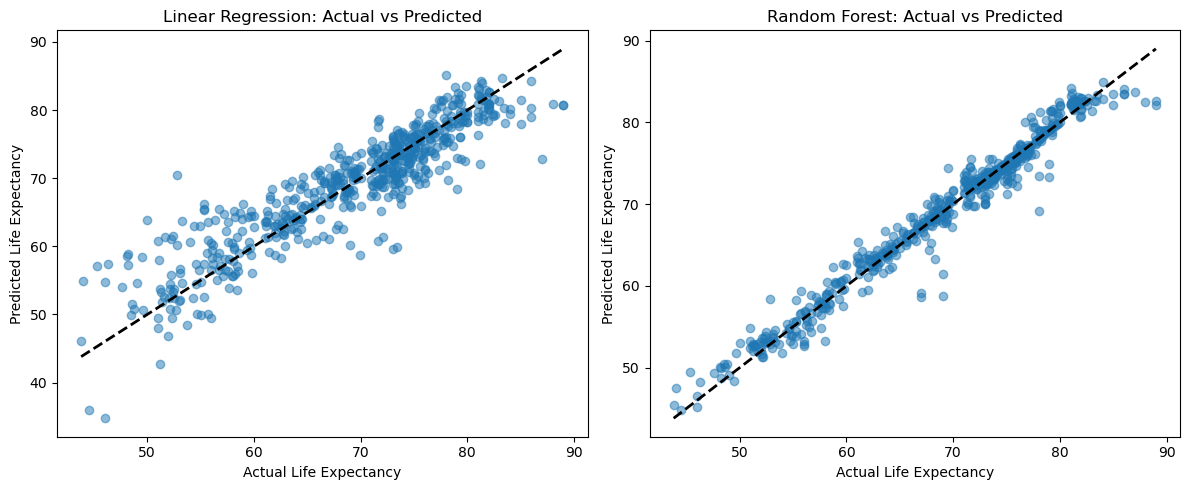

In [5]:
# Step 4: Generate at least 2 Evaluation Metrics on each algorithm

# evaluation metrics for Linear Regression
print("\n1. Linear Regression Evaluation:")
lr_mse = mean_squared_error(y_test, lr_pred)
lr_rmse = np.sqrt(lr_mse)  # Root Mean Squared Error
lr_mae = mean_absolute_error(y_test, lr_pred)  # Mean Absolute Error
lr_r2 = r2_score(y_test, lr_pred)  # R² Score

print(f"Mean Squared Error (MSE): {lr_mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {lr_rmse:.4f}")
print(f"Mean Absolute Error (MAE): {lr_mae:.4f}")
print(f"R² Score: {lr_r2:.4f}")

# evaluation metrics for Random Forest
print("\n2. Random Forest Evaluation:")
rf_mse = mean_squared_error(y_test, rf_pred)
rf_rmse = np.sqrt(rf_mse)  # Root Mean Squared Error
rf_mae = mean_absolute_error(y_test, rf_pred)  # Mean Absolute Error
rf_r2 = r2_score(y_test, rf_pred)  # R² Score

print(f"Mean Squared Error (MSE): {rf_mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rf_rmse:.4f}")
print(f"Mean Absolute Error (MAE): {rf_mae:.4f}")
print(f"R² Score: {rf_r2:.4f}")

# visualize actual vs predicted values
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(y_test, lr_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
plt.title('Linear Regression: Actual vs Predicted')
plt.xlabel('Actual Life Expectancy')
plt.ylabel('Predicted Life Expectancy')

plt.subplot(1, 2, 2)
plt.scatter(y_test, rf_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
plt.title('Random Forest: Actual vs Predicted')
plt.xlabel('Actual Life Expectancy')
plt.ylabel('Predicted Life Expectancy')

plt.tight_layout()
plt.savefig('eda_figures/life_expectancy_predictions.png')

               Model        MSE      RMSE       MAE        R2
0  Linear Regression  15.292306  3.910538  2.856357  0.823552
1      Random Forest   2.749005  1.658012  1.084088  0.968281

Best model based on R² score: Random Forest


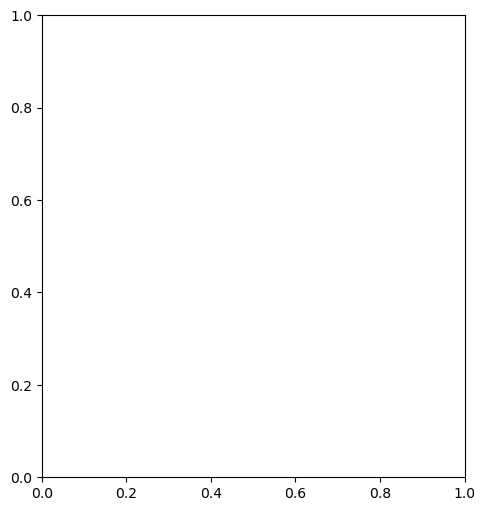

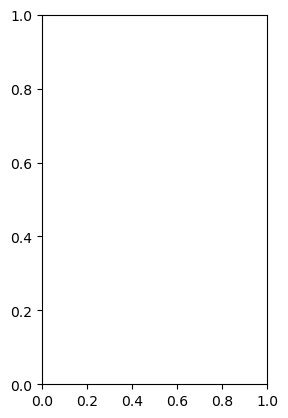

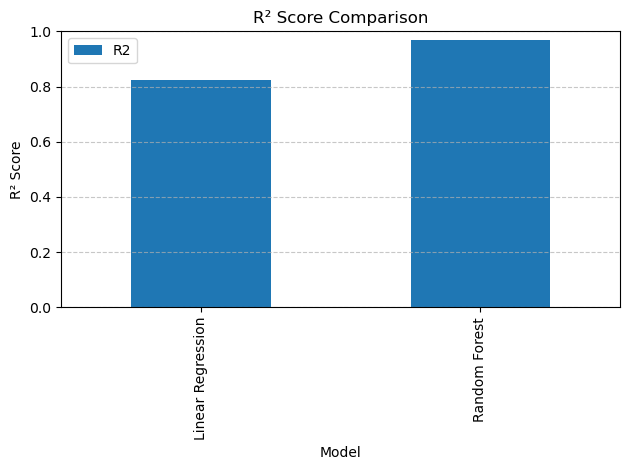

In [ ]:
# Step 5: Comparing the results

# create a comparison dataframe
comparison_df = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest'],
    'MSE': [lr_mse, rf_mse],
    'RMSE': [lr_rmse, rf_rmse],
    'MAE': [lr_mae, rf_mae],
    'R2': [lr_r2, rf_r2]
})
df_results = pd.DataFrame(comparison_df)
print(df_results)

# visualize model comparison
plt.figure(figsize=(12, 6))

# plot MSE, RMSE, and MAE
plt.subplot(1, 2, 1)
comparison_df[['Model', 'MSE', 'RMSE', 'MAE']].set_index('Model').plot(kind='bar')
plt.title('Error Metrics Comparison')
plt.ylabel('Error Value')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# plot R2
plt.subplot(1, 2, 2)
comparison_df[['Model', 'R2']].set_index('Model').plot(kind='bar')
plt.title('R² Score Comparison')
plt.ylabel('R² Score')
plt.ylim(0, 1)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig('eda_figures/life_expectancy_model_comparison.png')

# determine best model based on R2 score
best_model = 'Random Forest'
if lr_r2 > rf_r2: 
    best_model = 'Linear Regression'
print(f"\nBest model based on R² score: {best_model}")

Best parameters: {'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}
Best negative MSE: -3.9918131799268273

Tuned Random Forest Evaluation:
Mean Squared Error (MSE): 2.7513
Root Mean Squared Error (RMSE): 1.6587
Mean Absolute Error (MAE): 1.0839
R² Score: 0.9683

MSE Improvement: -0.08%

Top 15 Feature Importances:
                Feature  Importance
12             HIV_AIDS    0.593976
17   Income_composition    0.167012
1       Adult_Mortality    0.136980
7                   BMI    0.017364
8     under_five_deaths    0.011958
18            Schooling    0.010832
16   thinness_5_9_years    0.009087
0                  Year    0.007167
3               Alcohol    0.006708
15  thinness_1_19_years    0.005179
10    Total_expenditure    0.004987
13                  GDP    0.004290
2         infant_deaths    0.004262
6               Measles    0.004207
9                 Polio    0.003948

Task 2 (Regression) Summary:
------------------------------------------

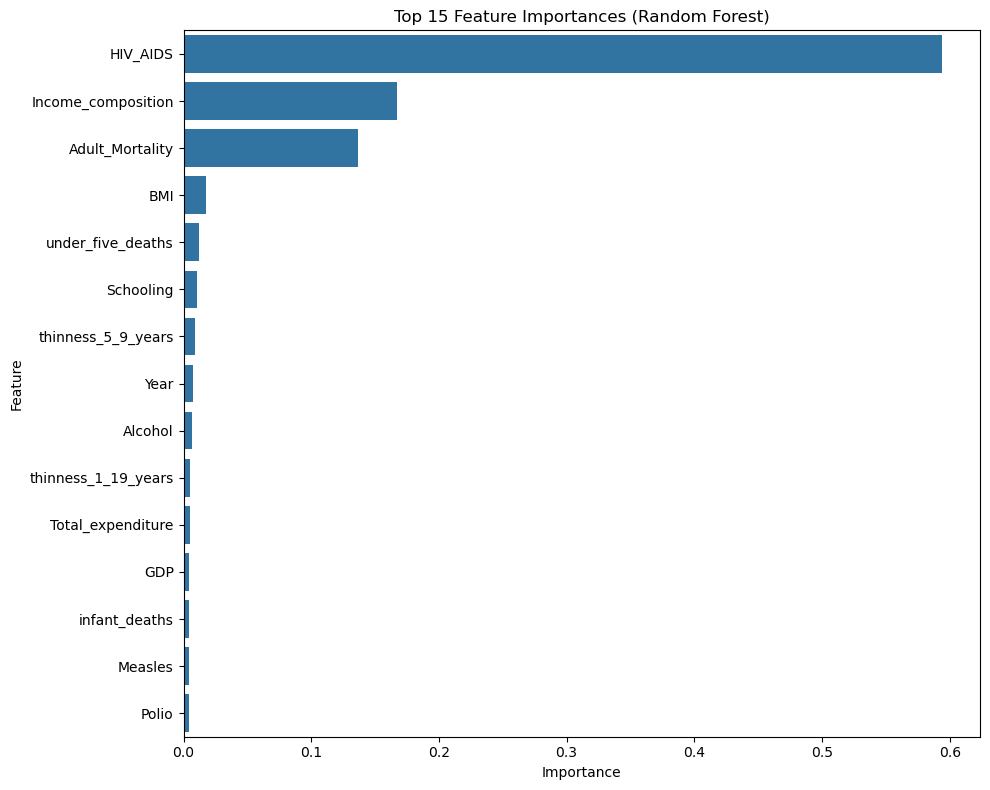

In [8]:
# Step 6: Fine Tune the best algorithm

if best_model == 'Linear Regression':
    # fine-tune using Ridge Regression (L2 regularization)
    print("16.1. Fine-tuning with Ridge Regression...")
    param_grid = {
        'alpha': [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]
    }
    
    grid_search = GridSearchCV(
        Ridge(random_state=42),
        param_grid,
        cv=5,
        scoring='neg_mean_squared_error',
        n_jobs=-1
    )
    
    grid_search.fit(X_train, y_train)
    
    print("Best parameters:", grid_search.best_params_)
    print("Best negative MSE:", grid_search.best_score_)
    
    # evaluate the tuned model
    tuned_lr = grid_search.best_estimator_
    tuned_lr_pred = tuned_lr.predict(X_test)
    
    tuned_lr_mse = mean_squared_error(y_test, tuned_lr_pred)
    tuned_lr_rmse = np.sqrt(tuned_lr_mse)
    tuned_lr_mae = mean_absolute_error(y_test, tuned_lr_pred)
    tuned_lr_r2 = r2_score(y_test, tuned_lr_pred)
    
    print("\nTuned Ridge Regression Evaluation:")
    print(f"Mean Squared Error (MSE): {tuned_lr_mse:.4f}")
    print(f"Root Mean Squared Error (RMSE): {tuned_lr_rmse:.4f}")
    print(f"Mean Absolute Error (MAE): {tuned_lr_mae:.4f}")
    print(f"R² Score: {tuned_lr_r2:.4f}")
    
    # compare tuned model with original
    mse_improvement = ((lr_mse - tuned_lr_mse) / lr_mse) * 100
    print(f"\nMSE Improvement: {mse_improvement:.2f}%")
    
    # feature importance for Linear Regression (coefficient analysis)
    feature_importance = pd.DataFrame({
        'Feature': X_train.columns,
        'Coefficient': np.abs(tuned_lr.coef_)
    })
    feature_importance = feature_importance.sort_values('Coefficient', ascending=False)
    
    plt.figure(figsize=(10, 8))
    sns.barplot(x='Coefficient', y='Feature', data=feature_importance.head(15))
    plt.title('Top 15 Feature Coefficients (Ridge Regression)')
    plt.tight_layout()
    plt.savefig('eda_figures/life_expectancy_ridge_coefficients.png')
    
    print("\nTop 15 Feature Coefficients:")
    print(feature_importance.head(15))
    
else:
    # fine-tune Random Forest
    param_grid = {
        'n_estimators': [100, 200, 300],
        'max_depth': [None, 10, 20, 30],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4]
    }
    
    grid_search = GridSearchCV(
        RandomForestRegressor(random_state=42),
        param_grid,
        cv=5,
        scoring='neg_mean_squared_error',
        n_jobs=-1
    )
    
    grid_search.fit(X_train, y_train)
    
    print("Best parameters:", grid_search.best_params_)
    print("Best negative MSE:", grid_search.best_score_)
    
    # evaluate the tuned model
    tuned_rf = grid_search.best_estimator_
    tuned_rf_pred = tuned_rf.predict(X_test)
    
    tuned_rf_mse = mean_squared_error(y_test, tuned_rf_pred)
    tuned_rf_rmse = np.sqrt(tuned_rf_mse)
    tuned_rf_mae = mean_absolute_error(y_test, tuned_rf_pred)
    tuned_rf_r2 = r2_score(y_test, tuned_rf_pred)
    
    print("\nTuned Random Forest Evaluation:")
    print(f"Mean Squared Error (MSE): {tuned_rf_mse:.4f}")
    print(f"Root Mean Squared Error (RMSE): {tuned_rf_rmse:.4f}")
    print(f"Mean Absolute Error (MAE): {tuned_rf_mae:.4f}")
    print(f"R² Score: {tuned_rf_r2:.4f}")
    
    # compare tuned model with original
    mse_improvement = ((rf_mse - tuned_rf_mse) / rf_mse) * 100
    print(f"\nMSE Improvement: {mse_improvement:.2f}%")
    
    # feature importance for Random Forest
    feature_importance = pd.DataFrame({
        'Feature': X_train.columns,
        'Importance': tuned_rf.feature_importances_
    })
    feature_importance = feature_importance.sort_values('Importance', ascending=False)
    
    plt.figure(figsize=(10, 8))
    sns.barplot(x='Importance', y='Feature', data=feature_importance.head(15))
    plt.title('Top 15 Feature Importances (Random Forest)')
    plt.tight_layout()
    plt.savefig('eda_figures/life_expectancy_rf_importances.png')
    
    print("\nTop 15 Feature Importances:")
    print(feature_importance.head(15))

# summary
print("\nTask 2 (Regression) Summary:")
print("-" * 50)
if best_model == 'Linear Regression':
    print(f"Best Model: Tuned Ridge Regression")
    print(f"Best Parameters: {grid_search.best_params_}")
    print(f"Final R² Score: {tuned_lr_r2:.4f}")
    print(f"Final RMSE: {tuned_lr_rmse:.4f} (Improvement of {mse_improvement:.2f}%)")
else:
    print(f"Best Model: Tuned Random Forest")
    print(f"Best Parameters: {grid_search.best_params_}")
    print(f"Final R² Score: {tuned_rf_r2:.4f}")
    print(f"Final RMSE: {tuned_rf_rmse:.4f} (Improvement of {mse_improvement:.2f}%)")

print("\nTop 3 Most Important Features:")
print(feature_importance.head(3))
print("-" * 50)

print("\nTask 2 (Regression) completed successfully!")